# Colorado Medicare Part D — Stage 3 Analysis

**Research question (from the proposal):** which dimensions actually drive
cost-per-claim variation among Colorado Part D prescribers, and which
prescribers are genuine unit-cost outliers rather than just members of an
expensive specialty?

**The one statistical step in this notebook:** a group comparison
(one-way ANOVA + Kruskal-Wallis) testing whether specialty and region are
real sources of cost-per-claim variation rather than noise, followed by a
**within-specialty percentile ranking** that re-scores every prescriber
against their own peer group.

**Method substitution.** The proposal said "regression." The course never
taught regression beyond `sns.regplot()` — no coefficient tables, no
R-squared, no `statsmodels` or `scikit-learn` (see `CALIBRATION.md` section 2).
The taught substitute for "which dimension drives cost" is one-way ANOVA
(`scipy.stats.f_oneway`) plus Kruskal-Wallis (`scipy.stats.kruskal`) with
`groupby().agg()` group means and `.quantile()` spreads, all covered in
Advanced Pandas II. That is what is used here. This substitution is also
recorded in `FINDINGS.md`.

**Data source.** `part_d_co_clean.csv` — the single cleaned file written in
Stage 0, 390,473 rows. The raw CSV is not re-read.

In [1]:
# WHAT: load the only libraries the bootcamp actually used.
# WHY:  CALIBRATION.md rule 1 caps imports at pandas, numpy, matplotlib,
#       seaborn, scipy.stats and pathlib. Nothing else appeared in a lecture
#       or a workshop, so nothing else is imported here.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path

# WHAT: set one consistent seaborn look and make a folder for the charts.
# WHY:  sns.set_theme was taught in Intro to Seaborn; a single theme keeps
#       every figure in the deck visually consistent.
sns.set_theme(style="whitegrid")
CHART_DIR = Path("charts")
CHART_DIR.mkdir(exist_ok=True)

# WHAT: a helper that formats an axis in dollars.
# WHY:  plt.FuncFormatter was used in Caleb's own wk12 workshop; raw axis
#       numbers like 250000000 are unreadable in a presentation.
dollars = plt.FuncFormatter(lambda x, pos: f"${x:,.0f}")
print("libraries loaded")

libraries loaded


## 1. Load the cleaned dataset and confirm it is the file Stage 0 signed off on

In [2]:
# WHAT: read the cleaned Stage 0 file.
# WHY:  every later stage reads this one file, never the raw CSV, so the
#       machine only ever holds one copy of the data (project storage rule).
#       encoding='utf-8-sig' strips the byte-order mark CMS ships in the file.
df = pd.read_csv("part_d_co_clean.csv", encoding="utf-8-sig", low_memory=False)

# WHAT: print the shape and the three headline totals.
# WHY:  this is the reconciliation check. If these do not match the numbers
#       verified in Stage 0, every finding below is built on the wrong file.
print("rows, columns :", df.shape)
print("total drug cost: $", round(df["Tot_Drug_Cst"].sum(), 2))
print("total claims   :", int(df["Tot_Clms"].sum()))
print("distinct NPIs  :", df["Prscrbr_NPI"].nunique())
print("distinct specialties:", df["Prscrbr_Type"].nunique())
print("distinct generics   :", df["Gnrc_Name"].nunique())
print("distinct cities     :", df["Prscrbr_City"].nunique())

rows, columns : (390473, 24)
total drug cost: $ 2737455388.61
total claims   : 16573710
distinct NPIs  : 19390
distinct specialties: 97
distinct generics   : 1177
distinct cities     : 226


In [3]:
# WHAT: look at the first few rows and the column list.
# WHY:  .head() and .info() are the standard first look taught in Intro to
#       Pandas I; they confirm the two derived columns survived the load.
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 390473 entries, 0 to 390472
Data columns (total 24 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Prscrbr_NPI            390473 non-null  int64  
 1   Prscrbr_Last_Org_Name  390473 non-null  object 
 2   Prscrbr_First_Name     390473 non-null  object 
 3   Prscrbr_City           390473 non-null  object 
 4   Prscrbr_State_Abrvtn   390473 non-null  object 
 5   Prscrbr_State_FIPS     390473 non-null  int64  
 6   Prscrbr_Type           390473 non-null  object 
 7   Prscrbr_Type_Src       390473 non-null  object 
 8   Brnd_Name              390473 non-null  object 
 9   Gnrc_Name              390473 non-null  object 
 10  Tot_Clms               390473 non-null  int64  
 11  Tot_30day_Fills        390473 non-null  float64
 12  Tot_Day_Suply          390473 non-null  int64  
 13  Tot_Drug_Cst           390473 non-null  float64
 14  Tot_Benes              160561 non-nu

,Prscrbr_NPI,Prscrbr_Last_Org_Name,Prscrbr_First_Name,Prscrbr_City,Prscrbr_State_Abrvtn,Prscrbr_State_FIPS,Prscrbr_Type,Prscrbr_Type_Src,Brnd_Name,Gnrc_Name,...,Tot_Benes,GE65_Sprsn_Flag,GE65_Tot_Clms,GE65_Tot_30day_Fills,GE65_Tot_Drug_Cst,GE65_Tot_Day_Suply,GE65_Bene_Sprsn_Flag,GE65_Tot_Benes,cost_per_claim,cost_per_30day_fill
0,1003000480,Rothchild,Kevin,Aurora,CO,8,General Surgery,Claim-Specialty,Omeprazole,Omeprazole,...,NaN,*,NaN,NaN,NaN,NaN,*,NaN,50.215385,17.044386
1,1003001256,Caragol,Jennifer,Evans,CO,8,Family Practice,Claim-Specialty,Alendronate Sodium,Alendronate Sodium,...,NaN,*,NaN,NaN,NaN,NaN,*,NaN,12.286364,4.387987
2,1003001256,Caragol,Jennifer,Evans,CO,8,Family Practice,Claim-Specialty,Amlodipine Besylate,Amlodipine Besylate,...,NaN,NaN,27.0,77.0,179.69,2310.0,*,NaN,6.655185,2.333636
3,1003001256,Caragol,Jennifer,Evans,CO,8,Family Practice,Claim-Specialty,Atorvastatin Calcium,Atorvastatin Calcium,...,11.0,NaN,47.0,115.0,360.65,3443.0,NaN,11.0,7.673404,3.136087
4,1003001256,Caragol,Jennifer,Evans,CO,8,Family Practice,Claim-Specialty,Fluticasone Propionate,Fluticasone Propionate,...,NaN,NaN,19.0,19.0,332.94,570.0,*,NaN,17.523158,17.523158


## 2. Roll the row-level data up to one row per prescriber

The file is one row per prescriber *per drug*. Every question in the proposal
is about prescribers, so the first move is a `groupby().agg()` to prescriber
level. Cost-per-claim is recomputed from the summed totals rather than
averaged from the row-level column — averaging a ratio would weight a
12-claim drug the same as a 12,000-claim drug.

In [4]:
# WHAT: collapse 390,473 drug-level rows into one row per prescriber.
# WHY:  grouping by NPI *together with* specialty and city (both constant for
#       a given NPI) carries those labels through without needing a 'first'
#       aggregation, and the row count afterwards proves they really are 1:1.
presc = (
    df.groupby(["Prscrbr_NPI", "Prscrbr_Last_Org_Name", "Prscrbr_Type", "Prscrbr_City"])
      .agg(total_cost=("Tot_Drug_Cst", "sum"),
           total_claims=("Tot_Clms", "sum"),
           total_30day_fills=("Tot_30day_Fills", "sum"),
           total_day_supply=("Tot_Day_Suply", "sum"),
           drugs_prescribed=("Gnrc_Name", "nunique"))
      .reset_index()
)

# WHAT: recompute the two unit-cost metrics from the summed totals.
# WHY:  cost-per-claim is a ratio of sums, not a mean of ratios. The proposal
#       named these two as the primary metrics because the beneficiary count
#       is blank on 58.9% of rows and cannot support a cost-per-beneficiary.
presc["cost_per_claim"] = presc["total_cost"] / presc["total_claims"]
presc["cost_per_30day_fill"] = presc["total_cost"] / presc["total_30day_fills"]

print("prescriber rows:", len(presc), " (expected 19,390 if NPI maps 1:1 to specialty and city)")
print("cost reconciles :", round(presc['total_cost'].sum(), 2))
print("claims reconcile:", int(presc['total_claims'].sum()))
presc.head()

prescriber rows: 19390  (expected 19,390 if NPI maps 1:1 to specialty and city)
cost reconciles : 2737455388.61
claims reconcile: 16573710


,Prscrbr_NPI,Prscrbr_Last_Org_Name,Prscrbr_Type,Prscrbr_City,total_cost,total_claims,total_30day_fills,total_day_supply,drugs_prescribed,cost_per_claim,cost_per_30day_fill
0,1003000480,Rothchild,General Surgery,Aurora,652.80,13,38.3,1150,1,50.215385,17.044386
1,1003001256,Caragol,Family Practice,Evans,22293.25,334,677.1,20121,17,66.746257,32.924605
2,1003004771,Riggle,Critical Care (Intensivists),Littleton,435972.96,723,1097.9,31273,14,603.005477,397.097149
3,1003011404,Mccoppin,Dermatology,Loveland,6156.91,377,419.9,8584,11,16.331326,14.662801
4,1003014853,Kray,Physician Assistant,Loveland,12249.37,36,64.0,1898,3,340.260278,191.396406


In [5]:
# WHAT: describe the prescriber-level cost-per-claim.
# WHY:  .describe() plus .quantile() is the taught way to see the shape of a
#       distribution. The gap between the mean and the median is the first
#       piece of evidence that this variable is heavily right-skewed, which
#       decides which statistical test is trustworthy later.
print(presc["cost_per_claim"].describe())
for q in [0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]:
    print(f"p{int(q*100):<3} cost per claim: ${presc['cost_per_claim'].quantile(q):,.2f}")

count     19390.000000
mean        193.649909
std        1298.474146
min           0.000000
25%           7.351997
50%          31.090716
75%          97.775937
max      111270.610714
Name: cost_per_claim, dtype: float64
p10  cost per claim: $3.98
p25  cost per claim: $7.35
p50  cost per claim: $31.09
p75  cost per claim: $97.78
p90  cost per claim: $314.83
p95  cost per claim: $656.32
p99  cost per claim: $2,990.50


## 3. Apply the >= 30 prescriber rule

The proposal fixed the comparison rule: a specialty only enters a
within-specialty comparison if it has at least 30 distinct prescribers. With
97 specialties in the file, many hold a handful of clinicians and a single
person would swing the group. The same guard is applied to cities.

In [6]:
# WHAT: count prescribers per specialty and keep only those with 30 or more.
# WHY:  .value_counts() gives the counts and .merge() attaches them back to
#       each prescriber row. A groupby .transform() would be shorter but was
#       never taught, so the merge is used instead.
spec_counts = presc["Prscrbr_Type"].value_counts().reset_index()
spec_counts.columns = ["Prscrbr_Type", "prescribers_in_specialty"]
presc = presc.merge(spec_counts, on="Prscrbr_Type", how="left")

city_counts = presc["Prscrbr_City"].value_counts().reset_index()
city_counts.columns = ["Prscrbr_City", "prescribers_in_city"]
presc = presc.merge(city_counts, on="Prscrbr_City", how="left")

qual_spec = presc[presc["prescribers_in_specialty"] >= 30].copy()
qual_city = presc[presc["prescribers_in_city"] >= 30].copy()

print("specialties with >= 30 prescribers:", qual_spec["Prscrbr_Type"].nunique(), "of", presc["Prscrbr_Type"].nunique())
print("  prescribers covered:", len(qual_spec), f"({len(qual_spec)/len(presc):.1%} of all prescribers)")
print("  spend covered: $", round(qual_spec['total_cost'].sum(), 2), f"({qual_spec['total_cost'].sum()/presc['total_cost'].sum():.1%} of state spend)")
print("cities with >= 30 prescribers:", qual_city["Prscrbr_City"].nunique(), "of", presc["Prscrbr_City"].nunique())
print("  prescribers covered:", len(qual_city), f"({len(qual_city)/len(presc):.1%})")

specialties with >= 30 prescribers: 46 of 97
  prescribers covered: 18940 (97.7% of all prescribers)
  spend covered: $ 2655447283.2 (97.0% of state spend)
cities with >= 30 prescribers: 60 of 226
  prescribers covered: 18394 (94.9%)


## 4. THE STATISTICAL STEP — is specialty real signal, or noise?

**Null hypothesis:** the median cost-per-claim is the same in every specialty;
any difference we see is sampling noise.

Two tests are run on the same data:

- **One-way ANOVA** (`scipy.stats.f_oneway`) — the parametric test taught in
  Advanced Pandas II. It assumes roughly normal groups with similar spread.
- **Kruskal-Wallis** (`scipy.stats.kruskal`) — the non-parametric equivalent,
  also taught in Advanced Pandas II. It ranks values instead of using them
  directly, so a handful of extreme prescribers cannot drag a group mean.

Section 2 showed cost-per-claim is severely right-skewed, so **Kruskal-Wallis
is the test being relied on** and ANOVA is reported alongside it for
completeness. The same pair is then run across cities, so the two dimensions
can be judged on the same evidence.

In [7]:
# WHAT: build one list of cost-per-claim values per specialty, then run both tests.
# WHY:  both scipy functions take the groups as separate arguments. Building
#       the list with a comprehension over the unique specialty names uses only
#       basic boolean filtering, which is taught in Intro to Pandas II.
spec_names = sorted(qual_spec["Prscrbr_Type"].unique())
spec_groups = [qual_spec.loc[qual_spec["Prscrbr_Type"] == s, "cost_per_claim"].values
               for s in spec_names]

f_stat_spec, p_anova_spec = stats.f_oneway(*spec_groups)
h_stat_spec, p_kw_spec = stats.kruskal(*spec_groups)

print(f"SPECIALTY  ({len(spec_names)} groups, {len(qual_spec):,} prescribers)")
print(f"  one-way ANOVA   F = {f_stat_spec:,.2f}   p = {p_anova_spec:.3g}")
print(f"  Kruskal-Wallis  H = {h_stat_spec:,.2f}   p = {p_kw_spec:.3g}")

SPECIALTY  (46 groups, 18,940 prescribers)
  one-way ANOVA   F = 51.83   p = 0
  Kruskal-Wallis  H = 8,608.94   p = 0


In [8]:
# WHAT: run exactly the same two tests across qualifying cities.
# WHY:  the proposal asks which dimension drives cost. Running an identical
#       test on a second dimension is what makes the two answers comparable.
city_names = sorted(qual_city["Prscrbr_City"].unique())
city_groups = [qual_city.loc[qual_city["Prscrbr_City"] == ct, "cost_per_claim"].values
               for ct in city_names]

f_stat_city, p_anova_city = stats.f_oneway(*city_groups)
h_stat_city, p_kw_city = stats.kruskal(*city_groups)

print(f"CITY  ({len(city_names)} groups, {len(qual_city):,} prescribers)")
print(f"  one-way ANOVA   F = {f_stat_city:,.2f}   p = {p_anova_city:.3g}")
print(f"  Kruskal-Wallis  H = {h_stat_city:,.2f}   p = {p_kw_city:.3g}")

CITY  (60 groups, 18,394 prescribers)
  one-way ANOVA   F = 3.17   p = 3.77e-15
  Kruskal-Wallis  H = 254.96   p = 3.44e-26


In [9]:
# WHAT: compare how far apart the GROUP MEDIANS sit on each dimension.
# WHY:  a p-value only says "not noise" -- it does not say how much the
#       dimension matters. H statistics from groups of different sizes are
#       not directly comparable either. The honest comparison is the spread of
#       the group medians themselves, computed with groupby().median() and
#       .quantile(), both taught in Advanced Pandas I.
spec_med = qual_spec.groupby("Prscrbr_Type")["cost_per_claim"].median()
city_med = qual_city.groupby("Prscrbr_City")["cost_per_claim"].median()

dispersion = pd.DataFrame({
    "dimension": ["Specialty", "City"],
    "groups": [len(spec_med), len(city_med)],
    "min_group_median": [spec_med.min(), city_med.min()],
    "p25": [spec_med.quantile(0.25), city_med.quantile(0.25)],
    "median_of_medians": [spec_med.median(), city_med.median()],
    "p75": [spec_med.quantile(0.75), city_med.quantile(0.75)],
    "max_group_median": [spec_med.max(), city_med.max()],
})
dispersion["p75_over_p25_fold"] = dispersion["p75"] / dispersion["p25"]
dispersion["max_over_min_fold"] = dispersion["max_group_median"] / dispersion["min_group_median"]
dispersion.round(2)

,dimension,groups,min_group_median,p25,median_of_medians,p75,max_group_median,p75_over_p25_fold,max_over_min_fold
0,Specialty,46,3.89,18.26,48.36,205.15,2272.07,11.23,584.53
1,City,60,4.38,20.83,29.65,37.60,79.71,1.81,18.21


## 5. Within-specialty percentile ranking — separating "expensive specialty" from "expensive prescriber"

Section 4 establishes that specialty is a real driver. That creates a problem
for oversight: a statewide top-percentile cost-per-claim list is mostly a list
of oncologists and geneticists, which is expected and not actionable.

The fix is to re-score every prescriber **against their own specialty**. The
95th percentile of cost-per-claim is computed separately inside each of the
46 qualifying specialties, merged back, and each prescriber flagged against
their own peer threshold.

In [10]:
# WHAT: compute per-specialty cost-per-claim percentiles and merge them back.
# WHY:  groupby().quantile() then .merge() is the taught route to a
#       within-group threshold. A groupby .transform() would do it in one line
#       but was never taught, so it is avoided on purpose.
spec_thresholds = (
    qual_spec.groupby("Prscrbr_Type")["cost_per_claim"]
             .quantile([0.25, 0.50, 0.75, 0.95])
             .unstack()
             .reset_index()
)
spec_thresholds.columns = ["Prscrbr_Type", "spec_p25", "spec_median", "spec_p75", "spec_p95"]

qual_spec = qual_spec.merge(spec_thresholds, on="Prscrbr_Type", how="left")

# WHAT: flag a prescriber if their cost-per-claim clears their OWN specialty's p95.
# WHY:  this is the within-specialty outlier definition. A comparison against
#       the statewide p95 would just re-find the expensive specialties.
qual_spec["within_spec_outlier"] = qual_spec["cost_per_claim"] > qual_spec["spec_p95"]

# WHAT: also flag against the statewide p95, for the comparison in the next cell.
statewide_p95 = presc["cost_per_claim"].quantile(0.95)
qual_spec["statewide_outlier"] = qual_spec["cost_per_claim"] > statewide_p95

print(f"statewide 95th percentile cost per claim: ${statewide_p95:,.2f}")
print("within-specialty outliers:", int(qual_spec['within_spec_outlier'].sum()))
print("statewide outliers        :", int(qual_spec['statewide_outlier'].sum()))
spec_thresholds.sort_values("spec_p95", ascending=False).head(10).round(2)

statewide 95th percentile cost per claim: $656.32
within-specialty outliers: 965
statewide outliers        : 929


,Prscrbr_Type,spec_p25,spec_median,spec_p75,spec_p95
31,Pediatric Medicine,19.27,61.31,262.76,9952.17
5,Critical Care (Intensivists),370.85,484.37,884.03,6864.98
15,Hematology-Oncology,1275.32,2272.07,3474.99,5967.16
20,Medical Oncology,823.78,1673.05,3013.59,5622.50
39,Pulmonary Disease,370.18,517.36,882.80,5397.80
17,Infectious Disease,201.46,829.78,1556.47,3093.78
22,Neurology,99.54,251.01,516.81,2842.74
41,Rheumatology,478.34,800.17,1291.36,2310.67
11,Gastroenterology,37.35,114.48,401.63,1942.43
0,Allergy/ Immunology,265.40,426.18,721.02,1789.93


In [11]:
# WHAT: cross-tabulate the two flags.
# WHY:  the overlap is the whole point. Prescribers flagged statewide but NOT
#       within their specialty are explained by case mix -- that is the signal
#       the specialty effect already accounts for. Prescribers flagged inside
#       their own specialty are the ones a reviewer cannot explain away.
overlap = qual_spec.groupby(["statewide_outlier", "within_spec_outlier"]).agg(
    prescribers=("Prscrbr_NPI", "count"),
    total_cost=("total_cost", "sum"),
).reset_index()
overlap["pct_of_qualifying_spend"] = 100 * overlap["total_cost"] / qual_spec["total_cost"].sum()

both = int(((qual_spec['statewide_outlier']) & (qual_spec['within_spec_outlier'])).sum())
stateonly = int(((qual_spec['statewide_outlier']) & (~qual_spec['within_spec_outlier'])).sum())
speconly = int(((~qual_spec['statewide_outlier']) & (qual_spec['within_spec_outlier'])).sum())
print(f"flagged BOTH ways                 : {both:,}")
print(f"flagged statewide ONLY (case mix) : {stateonly:,}  <- explained by specialty")
print(f"flagged within-specialty ONLY     : {speconly:,}  <- invisible on a statewide list")
overlap.round(2)

flagged BOTH ways                 : 498
flagged statewide ONLY (case mix) : 431  <- explained by specialty
flagged within-specialty ONLY     : 467  <- invisible on a statewide list


,statewide_outlier,within_spec_outlier,prescribers,total_cost,pct_of_qualifying_spend
0,False,False,17544,1.528897e+09,57.58
1,False,True,467,8.462492e+07,3.19
2,True,False,431,5.394030e+08,20.31
3,True,True,498,5.025224e+08,18.92


In [12]:
# WHAT: test whether within-specialty unit-cost outliers also carry
#       disproportionate TOTAL spend.
# WHY:  cost-per-claim was the ranking variable, so re-testing it would be
#       circular. Total cost is an independent measure. Kruskal-Wallis on two
#       groups is the non-parametric two-sample test; the taught t-test
#       (ttest_ind) is reported next to it, but total cost is even more skewed
#       than cost-per-claim so the rank-based result is the one relied on.
out_cost = qual_spec.loc[qual_spec["within_spec_outlier"], "total_cost"].values
rest_cost = qual_spec.loc[~qual_spec["within_spec_outlier"], "total_cost"].values

h_cost, p_kw_cost = stats.kruskal(out_cost, rest_cost)
t_cost, p_t_cost = stats.ttest_ind(out_cost, rest_cost, equal_var=False)

print(f"within-specialty outliers : n = {len(out_cost):,}  median total cost = ${np.median(out_cost):,.2f}  mean = ${out_cost.mean():,.2f}")
print(f"everyone else             : n = {len(rest_cost):,}  median total cost = ${np.median(rest_cost):,.2f}  mean = ${rest_cost.mean():,.2f}")
print(f"  Kruskal-Wallis  H = {h_cost:,.2f}  p = {p_kw_cost:.3g}")
print(f"  Welch t-test    t = {t_cost:,.2f}  p = {p_t_cost:.3g}")
print(f"outliers are {len(out_cost)/len(qual_spec):.1%} of qualifying prescribers and carry "
      f"{out_cost.sum()/qual_spec['total_cost'].sum():.1%} of qualifying spend (${out_cost.sum():,.2f})")

within-specialty outliers : n = 965  median total cost = $144,422.20  mean = $608,442.82
everyone else             : n = 17,975  median total cost = $4,924.29  mean = $115,065.37
  Kruskal-Wallis  H = 658.63  p = 2.97e-145
  Welch t-test    t = 11.11  p = 4.26e-27
outliers are 5.1% of qualifying prescribers and carry 22.1% of qualifying spend ($587,147,319.57)


In [13]:
# WHAT: rank the 46 qualifying specialties by how much of their own spend
#       their within-specialty outliers carry.
# WHY:  this turns the statistics into a priority list. A specialty where the
#       top 5% carry half the money is a different review problem from one
#       where they carry two percent.
spec_summary = qual_spec.groupby("Prscrbr_Type").agg(
    prescribers=("Prscrbr_NPI", "count"),
    outliers=("within_spec_outlier", "sum"),
    specialty_cost=("total_cost", "sum"),
    specialty_claims=("total_claims", "sum"),
    median_cpc=("cost_per_claim", "median"),
).reset_index()

outlier_cost = (qual_spec[qual_spec["within_spec_outlier"]]
                .groupby("Prscrbr_Type")["total_cost"].sum().reset_index()
                .rename(columns={"total_cost": "outlier_cost"}))
spec_summary = spec_summary.merge(outlier_cost, on="Prscrbr_Type", how="left")
spec_summary["outlier_cost"] = spec_summary["outlier_cost"].fillna(0)
spec_summary["specialty_cpc"] = spec_summary["specialty_cost"] / spec_summary["specialty_claims"]
spec_summary["pct_spend_in_outliers"] = 100 * spec_summary["outlier_cost"] / spec_summary["specialty_cost"]
spec_summary["pct_of_state_spend"] = 100 * spec_summary["specialty_cost"] / presc["total_cost"].sum()

# WHAT: the priority view -- specialties that are both large and outlier-heavy.
# WHY:  .sort_values() and .nlargest() are the taught ways to rank a table.
priority = spec_summary.sort_values("outlier_cost", ascending=False).head(12)
priority[["Prscrbr_Type", "prescribers", "outliers", "specialty_cost",
          "outlier_cost", "pct_spend_in_outliers", "pct_of_state_spend", "specialty_cpc"]].round(2)

,Prscrbr_Type,prescribers,outliers,specialty_cost,outlier_cost,pct_spend_in_outliers,pct_of_state_spend,specialty_cpc
24,Nurse Practitioner,3509,176,3.928301e+08,1.093431e+08,27.83,14.35,136.89
34,Physician Assistant,3010,151,2.563545e+08,1.066705e+08,41.61,9.36,146.95
18,Internal Medicine,1292,65,3.157638e+08,6.029321e+07,19.09,11.53,97.99
10,Family Practice,2288,115,3.521803e+08,4.133411e+07,11.74,12.87,72.84
15,Hematology-Oncology,115,6,2.277883e+08,3.304583e+07,14.51,8.32,2651.79
44,Urology,178,9,5.035253e+07,2.668584e+07,53.00,1.84,319.99
39,Pulmonary Disease,154,8,1.032829e+08,2.564208e+07,24.83,3.77,907.04
2,Cardiology,205,11,1.348944e+08,2.413391e+07,17.89,4.93,272.13
5,Critical Care (Intensivists),75,4,5.932893e+07,1.826635e+07,30.79,2.17,1491.05
20,Medical Oncology,76,4,8.551773e+07,1.683176e+07,19.68,3.12,2445.88


In [14]:
# WHAT: measure how concentrated total spend is across drugs and prescribers.
# WHY:  the proposal asks where the money is, and .nlargest() with a running
#       .sum() answers it without drawing an off-syllabus Pareto curve.
drug_cost = df.groupby("Gnrc_Name")["Tot_Drug_Cst"].sum().sort_values(ascending=False)
state_total = df["Tot_Drug_Cst"].sum()

for n in [10, 20, 50, 100]:
    print(f"top {n:>3} generic drugs = ${drug_cost.head(n).sum():>16,.2f}  "
          f"({100*drug_cost.head(n).sum()/state_total:5.1f}% of all spend)")

presc_cost = presc["total_cost"].sort_values(ascending=False)
for n in [100, 500, 1000, 1939]:
    print(f"top {n:>4} prescribers   = ${presc_cost.head(n).sum():>16,.2f}  "
          f"({100*presc_cost.head(n).sum()/state_total:5.1f}% of all spend)")
print(f"\ntop 1,939 prescribers is the top 10% of all {len(presc):,} prescribers")

top  10 generic drugs = $  917,805,669.50  ( 33.5% of all spend)
top  20 generic drugs = $1,246,696,781.68  ( 45.5% of all spend)
top  50 generic drugs = $1,784,983,783.87  ( 65.2% of all spend)
top 100 generic drugs = $2,163,263,642.96  ( 79.0% of all spend)
top  100 prescribers   = $  505,551,496.06  ( 18.5% of all spend)
top  500 prescribers   = $1,139,326,256.27  ( 41.6% of all spend)
top 1000 prescribers   = $1,534,359,204.56  ( 56.1% of all spend)
top 1939 prescribers   = $1,968,171,559.99  ( 71.9% of all spend)

top 1,939 prescribers is the top 10% of all 19,390 prescribers


## 6. Charts

Seven figures, all drawn with chart types from the Seaborn and Advanced
Pandas II lectures. The Stage 0 chart set used a Pareto curve, `ax.barh`,
`ax.fill_between` and a log axis, none of which were taught; those five
figures were moved to `charts/superseded/` and are replaced by these.

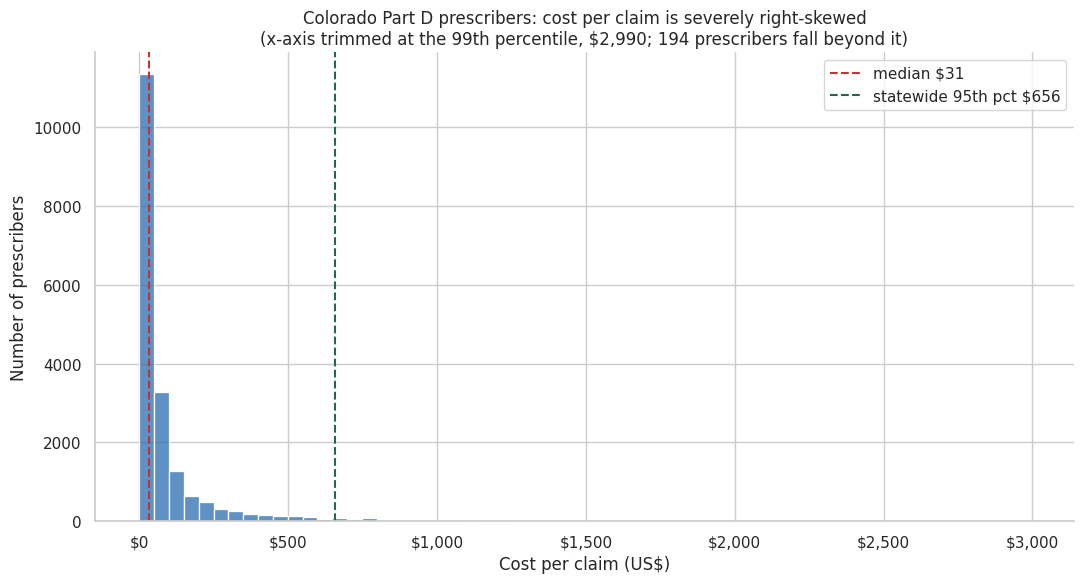

In [15]:
# CHART 1 -- WHAT: histogram of prescriber cost-per-claim, trimmed at the 99th percentile.
# WHY:  sns.histplot is taught in Intro to Seaborn. The trim is stated on the
#       chart, not hidden: without it the 99% of prescribers under $1,000 would
#       collapse into a single bar next to one $111,000 outlier. A log axis
#       would be the usual fix but was never taught.
cut99 = presc["cost_per_claim"].quantile(0.99)
plot_df = presc[presc["cost_per_claim"] <= cut99]

fig, ax = plt.subplots(figsize=(11, 6))
sns.histplot(data=plot_df, x="cost_per_claim", bins=60, color="#2b6cb0", ax=ax)
ax.axvline(presc["cost_per_claim"].median(), color="#c53030", linestyle="--",
           label=f"median ${presc['cost_per_claim'].median():,.0f}")
ax.axvline(statewide_p95, color="#276749", linestyle="--",
           label=f"statewide 95th pct ${statewide_p95:,.0f}")
ax.set_title("Colorado Part D prescribers: cost per claim is severely right-skewed\n"
             f"(x-axis trimmed at the 99th percentile, ${cut99:,.0f}; "
             f"{(presc['cost_per_claim'] > cut99).sum()} prescribers fall beyond it)")
ax.set_xlabel("Cost per claim (US$)")
ax.set_ylabel("Number of prescribers")
ax.xaxis.set_major_formatter(dollars)
ax.legend()
sns.despine()
plt.tight_layout()
plt.savefig(CHART_DIR / "stage3_01_cost_per_claim_distribution.png", dpi=150)
plt.show()

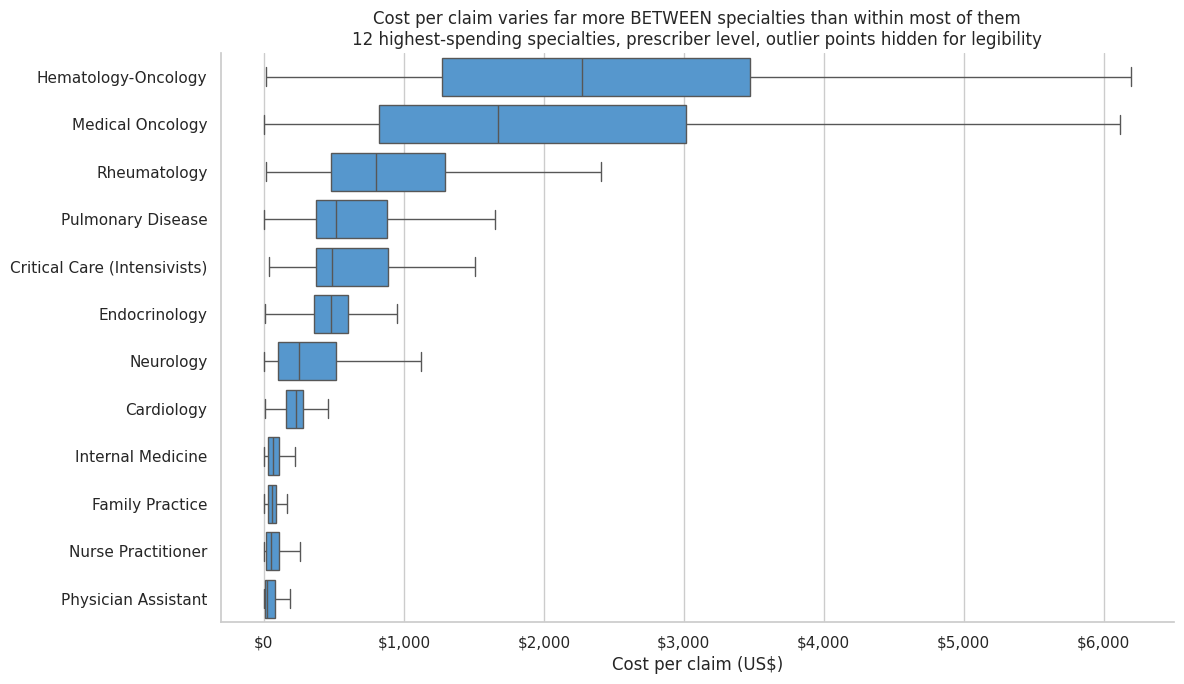

In [16]:
# CHART 2 -- WHAT: boxplot of cost-per-claim for the 12 highest-spending specialties.
# WHY:  sns.boxplot is taught in Intro to Seaborn and is the direct swap for
#       the raw matplotlib ax.boxplot used in the Stage 0 chart. showfliers=False
#       keeps the boxes legible; the flier count is named in the title instead.
top12 = spec_summary.nlargest(12, "specialty_cost")["Prscrbr_Type"].tolist()
box_df = qual_spec[qual_spec["Prscrbr_Type"].isin(top12)]
order12 = (box_df.groupby("Prscrbr_Type")["cost_per_claim"].median()
                 .sort_values(ascending=False).index.tolist())

fig, ax = plt.subplots(figsize=(12, 7))
sns.boxplot(data=box_df, y="Prscrbr_Type", x="cost_per_claim",
            order=order12, showfliers=False, color="#4299e1", ax=ax)
ax.set_title("Cost per claim varies far more BETWEEN specialties than within most of them\n"
             "12 highest-spending specialties, prescriber level, outlier points hidden for legibility")
ax.set_xlabel("Cost per claim (US$)")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(dollars)
sns.despine()
plt.tight_layout()
plt.savefig(CHART_DIR / "stage3_02_cost_per_claim_by_specialty_box.png", dpi=150)
plt.show()

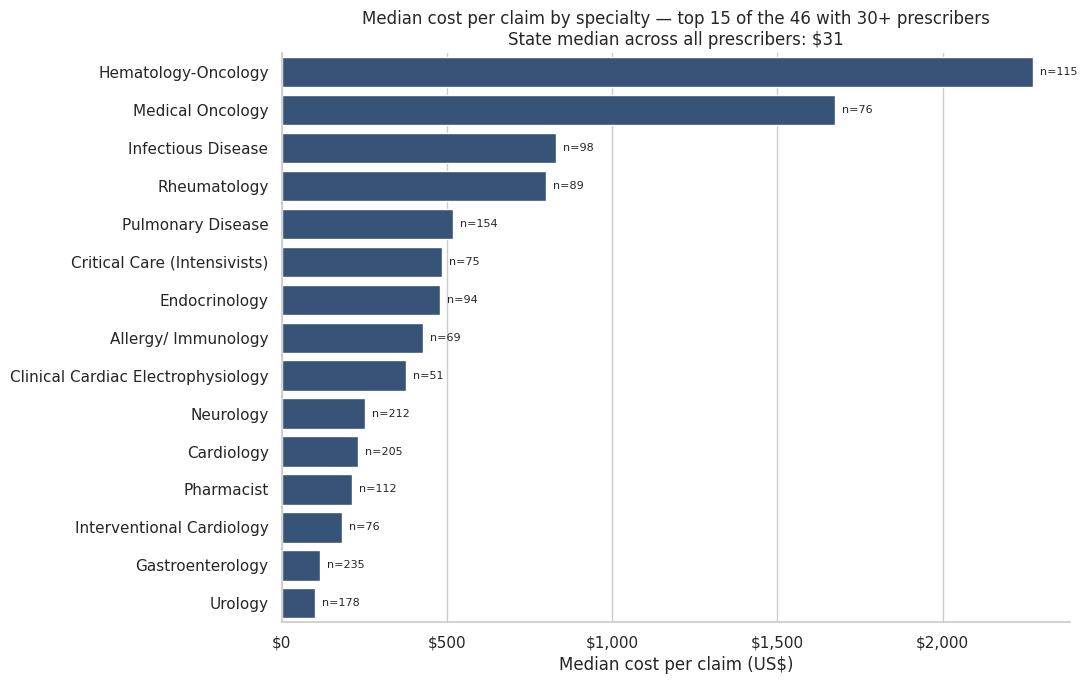

In [17]:
# CHART 3 -- WHAT: bar chart of median prescriber cost-per-claim, top 15 specialties.
# WHY:  sns.barplot is taught. The median is used rather than the mean because
#       Section 2 showed the mean is dragged by a handful of prescribers.
top15_cpc = spec_summary.nlargest(15, "median_cpc")

fig, ax = plt.subplots(figsize=(11, 7))
sns.barplot(data=top15_cpc, y="Prscrbr_Type", x="median_cpc", color="#2c5282", ax=ax)
ax.set_title("Median cost per claim by specialty — top 15 of the 46 with 30+ prescribers\n"
             f"State median across all prescribers: ${presc['cost_per_claim'].median():,.0f}")
ax.set_xlabel("Median cost per claim (US$)")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(dollars)
for i, (_, r) in enumerate(top15_cpc.iterrows()):
    ax.text(r["median_cpc"], i, f"  n={int(r['prescribers'])}", va="center", fontsize=8)
sns.despine()
plt.tight_layout()
plt.savefig(CHART_DIR / "stage3_03_median_cost_per_claim_by_specialty.png", dpi=150)
plt.show()

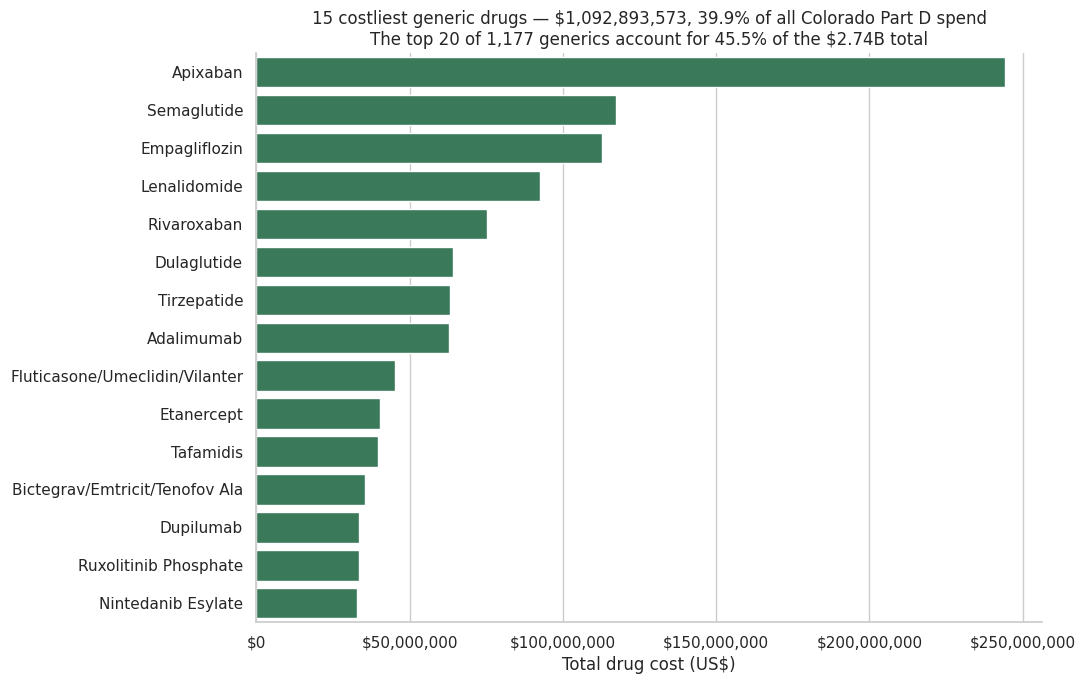

In [18]:
# CHART 4 -- WHAT: bar chart of the 15 costliest generic drugs.
# WHY:  replaces the Stage 0 Pareto chart, which used a cumulative-percent line
#       that was never taught. The concentration figure is stated in the title
#       instead of drawn as a curve.
top_drugs = drug_cost.head(15).reset_index()
top_drugs.columns = ["Gnrc_Name", "total_cost"]

fig, ax = plt.subplots(figsize=(11, 7))
sns.barplot(data=top_drugs, y="Gnrc_Name", x="total_cost", color="#2f855a", ax=ax)
ax.set_title(f"15 costliest generic drugs — ${top_drugs['total_cost'].sum():,.0f}, "
             f"{100*top_drugs['total_cost'].sum()/state_total:.1f}% of all Colorado Part D spend\n"
             f"The top 20 of 1,177 generics account for "
             f"{100*drug_cost.head(20).sum()/state_total:.1f}% of the ${state_total/1e9:.2f}B total")
ax.set_xlabel("Total drug cost (US$)")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(dollars)
sns.despine()
plt.tight_layout()
plt.savefig(CHART_DIR / "stage3_04_top15_generic_drugs_by_spend.png", dpi=150)
plt.show()

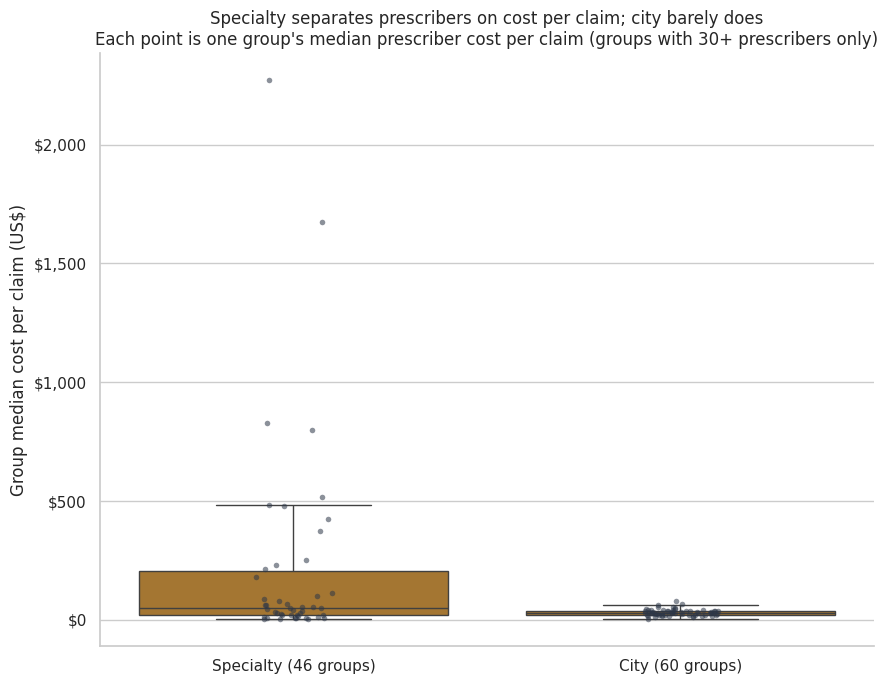

In [19]:
# CHART 5 -- WHAT: side-by-side boxplot of GROUP MEDIANS for specialty vs city.
# WHY:  this is the visual form of the dispersion table in Section 4, and it
#       replaces the Stage 0 'variance explained by dimension' chart that came
#       from an off-syllabus regression. Each point is one group's median, so
#       the taller box is the dimension that separates prescribers more.
dim_df = pd.concat([
    pd.DataFrame({"dimension": "Specialty (46 groups)", "group_median_cpc": spec_med.values}),
    pd.DataFrame({"dimension": "City (60 groups)", "group_median_cpc": city_med.values}),
])

fig, ax = plt.subplots(figsize=(9, 7))
sns.boxplot(data=dim_df, x="dimension", y="group_median_cpc", color="#b7791f",
            showfliers=False, ax=ax)  # fliers hidden: the stripplot below already draws every group
sns.stripplot(data=dim_df, x="dimension", y="group_median_cpc",
              color="#2d3748", alpha=0.55, size=4, ax=ax)
ax.set_title("Specialty separates prescribers on cost per claim; city barely does\n"
             "Each point is one group's median prescriber cost per claim "
             "(groups with 30+ prescribers only)")
ax.set_xlabel("")
ax.set_ylabel("Group median cost per claim (US$)")
ax.yaxis.set_major_formatter(dollars)
sns.despine()
plt.tight_layout()
plt.savefig(CHART_DIR / "stage3_05_group_median_dispersion_by_dimension.png", dpi=150)
plt.show()

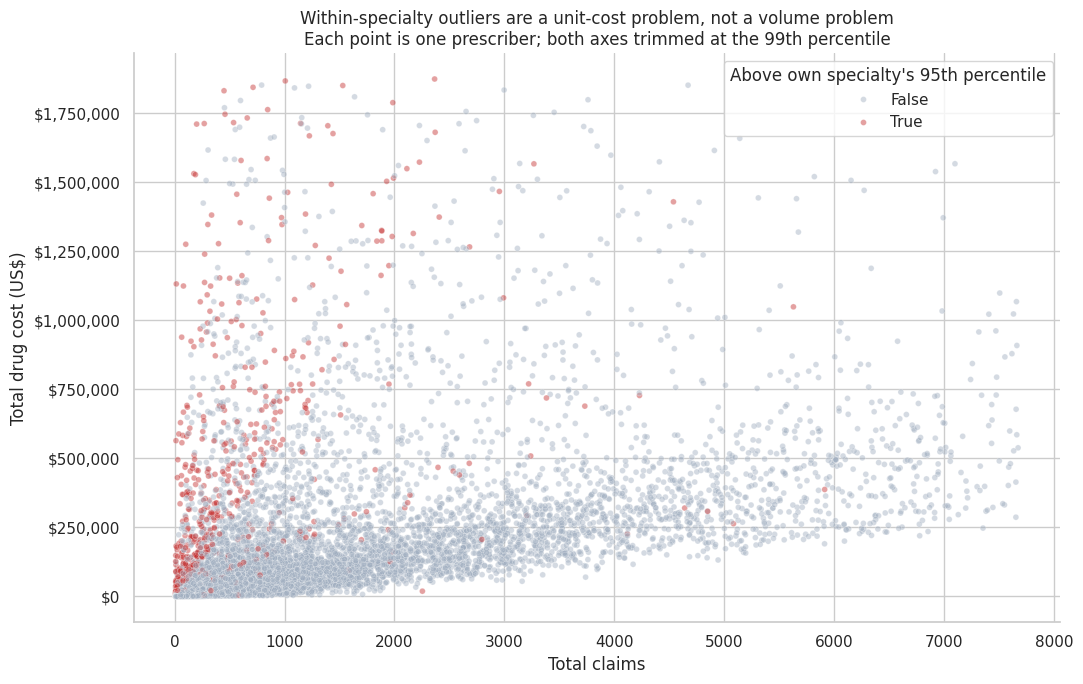

In [20]:
# CHART 6 -- WHAT: scatter of claims against total cost, coloured by the
#       within-specialty outlier flag.
# WHY:  sns.scatterplot is taught in Intro to Seaborn. It shows that the flag
#       is not simply picking out the biggest prescribers -- flagged points sit
#       high on cost at low claim volume, which is the definition of a unit-cost
#       problem rather than a volume one. Trimmed at the 99th percentile on
#       both axes for the same legibility reason as Chart 1.
sc = qual_spec[(qual_spec["total_claims"] <= qual_spec["total_claims"].quantile(0.99)) &
               (qual_spec["total_cost"] <= qual_spec["total_cost"].quantile(0.99))]

fig, ax = plt.subplots(figsize=(11, 7))
sns.scatterplot(data=sc, x="total_claims", y="total_cost",
                hue="within_spec_outlier", alpha=0.45, s=18,
                palette={True: "#c53030", False: "#a0aec0"}, ax=ax)
ax.set_title("Within-specialty outliers are a unit-cost problem, not a volume problem\n"
             "Each point is one prescriber; both axes trimmed at the 99th percentile")
ax.set_xlabel("Total claims")
ax.set_ylabel("Total drug cost (US$)")
ax.yaxis.set_major_formatter(dollars)
ax.legend(title="Above own specialty's 95th percentile")
sns.despine()
plt.tight_layout()
plt.savefig(CHART_DIR / "stage3_06_within_specialty_outliers_scatter.png", dpi=150)
plt.show()

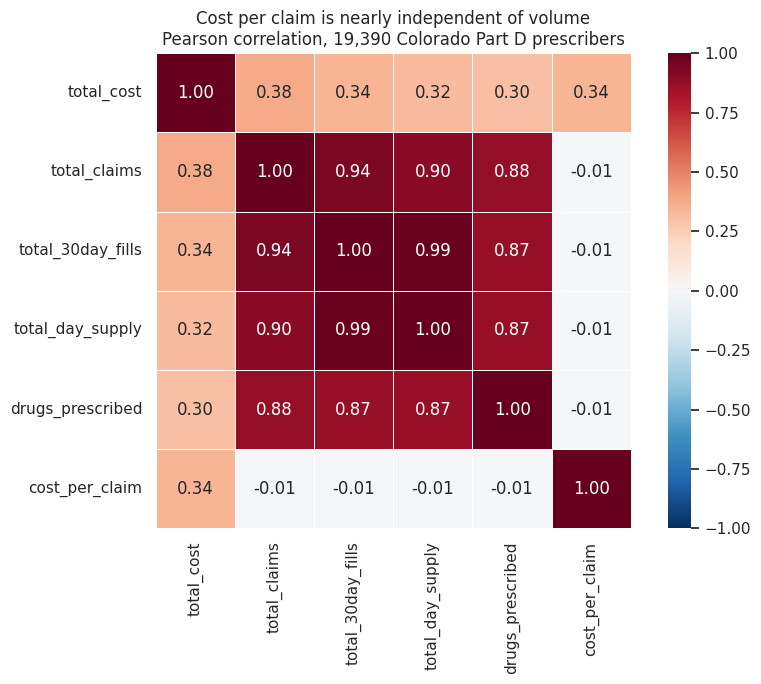

,total_cost,total_claims,total_30day_fills,total_day_supply,drugs_prescribed,cost_per_claim
total_cost,1.000,0.380,0.338,0.318,0.299,0.337
total_claims,0.380,1.000,0.944,0.904,0.881,-0.011
total_30day_fills,0.338,0.944,1.000,0.991,0.873,-0.015
total_day_supply,0.318,0.904,0.991,1.000,0.870,-0.014
drugs_prescribed,0.299,0.881,0.873,0.870,1.000,-0.012
cost_per_claim,0.337,-0.011,-0.015,-0.014,-0.012,1.000


In [21]:
# CHART 7 -- WHAT: correlation heatmap of the prescriber-level measures.
# WHY:  .corr() with sns.heatmap is the exact pairing taught in Advanced
#       Pandas II. It shows the volume measures move together almost perfectly
#       while cost-per-claim moves with none of them -- which is why a
#       high-volume prescriber list and a high-unit-cost list find different people.
corr_cols = ["total_cost", "total_claims", "total_30day_fills",
             "total_day_supply", "drugs_prescribed", "cost_per_claim"]
corr = presc[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)
ax.set_title("Cost per claim is nearly independent of volume\n"
             "Pearson correlation, 19,390 Colorado Part D prescribers")
plt.tight_layout()
plt.savefig(CHART_DIR / "stage3_07_prescriber_measure_correlation_heatmap.png", dpi=150)
plt.show()
corr.round(3)

## 7. Numbers carried into FINDINGS.md

Every figure quoted in `FINDINGS.md` is printed once here so it can be traced
back to the cell that produced it.

In [22]:
# WHAT: print, in one block, every number that appears in FINDINGS.md.
# WHY:  the quality rule for this stage is that every figure in the findings
#       traces to a notebook cell. This cell is that trace.
print("=" * 72)
print("STAGE 3 -- FIGURES USED IN FINDINGS.md")
print("=" * 72)
print(f"rows / prescribers / specialties / generics / cities : "
      f"{len(df):,} / {len(presc):,} / {df['Prscrbr_Type'].nunique()} / "
      f"{df['Gnrc_Name'].nunique():,} / {df['Prscrbr_City'].nunique()}")
print(f"total spend                                : ${state_total:,.2f}")
print(f"median prescriber cost per claim           : ${presc['cost_per_claim'].median():,.2f}")
print(f"mean prescriber cost per claim             : ${presc['cost_per_claim'].mean():,.2f}")
print(f"statewide 95th percentile cost per claim   : ${statewide_p95:,.2f}")
print()
print(f"F1  ANOVA specialty   F = {f_stat_spec:,.2f}  p = {p_anova_spec:.3g}")
print(f"F1  Kruskal specialty H = {h_stat_spec:,.2f}  p = {p_kw_spec:.3g}  (k={len(spec_names)}, n={len(qual_spec):,})")
print(f"F1  specialty group medians span ${spec_med.min():,.2f} to ${spec_med.max():,.2f} "
      f"({spec_med.max()/spec_med.min():,.1f}x)")
print()
print(f"F2  ANOVA city   F = {f_stat_city:,.2f}  p = {p_anova_city:.3g}")
print(f"F2  Kruskal city H = {h_stat_city:,.2f}  p = {p_kw_city:.3g}  (k={len(city_names)}, n={len(qual_city):,})")
print(f"F2  city group medians span ${city_med.min():,.2f} to ${city_med.max():,.2f} "
      f"({city_med.max()/city_med.min():,.1f}x)")
print(f"F2  specialty p75/p25 fold = {dispersion.loc[0,'p75_over_p25_fold']:.2f}x   "
      f"city p75/p25 fold = {dispersion.loc[1,'p75_over_p25_fold']:.2f}x")
print()
print(f"F3  within-specialty outliers : {int(qual_spec['within_spec_outlier'].sum()):,} prescribers "
      f"({qual_spec['within_spec_outlier'].mean():.1%} of {len(qual_spec):,} qualifying)")
print(f"F3  they carry ${out_cost.sum():,.2f} = {out_cost.sum()/qual_spec['total_cost'].sum():.1%} of qualifying spend")
print(f"F3  median total cost, outliers vs rest : ${np.median(out_cost):,.2f} vs ${np.median(rest_cost):,.2f}")
print(f"F3  Kruskal H = {h_cost:,.2f} p = {p_kw_cost:.3g} ; Welch t = {t_cost:,.2f} p = {p_t_cost:.3g}")
print()
print(f"F4  flagged statewide only (explained by specialty) : {stateonly:,}")
print(f"F4  flagged within-specialty only (missed statewide): {speconly:,}")
print(f"F4  flagged both ways                              : {both:,}")
print()
print(f"F5  top 20 of 1,177 generics = {100*drug_cost.head(20).sum()/state_total:.1f}% of spend "
      f"(${drug_cost.head(20).sum():,.2f})")
print(f"F5  top 100 generics         = {100*drug_cost.head(100).sum()/state_total:.1f}% of spend")
print(f"F5  top 10% of prescribers (1,939) = {100*presc_cost.head(1939).sum()/state_total:.1f}% of spend")
print(f"F5  corr(total_cost, total_claims)   = {corr.loc['total_cost','total_claims']:.3f}")
print(f"F5  corr(cost_per_claim, total_claims) = {corr.loc['cost_per_claim','total_claims']:.3f}")
print(f"F5  corr(cost_per_claim, total_cost)   = {corr.loc['cost_per_claim','total_cost']:.3f}")
print("=" * 72)

STAGE 3 -- FIGURES USED IN FINDINGS.md
rows / prescribers / specialties / generics / cities : 390,473 / 19,390 / 97 / 1,177 / 226
total spend                                : $2,737,455,388.61
median prescriber cost per claim           : $31.09
mean prescriber cost per claim             : $193.65
statewide 95th percentile cost per claim   : $656.32

F1  ANOVA specialty   F = 51.83  p = 0
F1  Kruskal specialty H = 8,608.94  p = 0  (k=46, n=18,940)
F1  specialty group medians span $3.89 to $2,272.07 (584.5x)

F2  ANOVA city   F = 3.17  p = 3.77e-15
F2  Kruskal city H = 254.96  p = 3.44e-26  (k=60, n=18,394)
F2  city group medians span $4.38 to $79.71 (18.2x)
F2  specialty p75/p25 fold = 11.23x   city p75/p25 fold = 1.81x

F3  within-specialty outliers : 965 prescribers (5.1% of 18,940 qualifying)
F3  they carry $587,147,319.57 = 22.1% of qualifying spend
F3  median total cost, outliers vs rest : $144,422.20 vs $4,924.29
F3  Kruskal H = 658.63 p = 2.97e-145 ; Welch t = 11.11 p = 4.26e-27


In [23]:
# WHAT: print the recommended priority segments, ranked.
# WHY:  these five rows are the recommendation in FINDINGS.md. Printing them
#       here means the recommendation is not an opinion typed into a document,
#       it is a sorted table with a rule behind it.
priority_out = spec_summary.sort_values("outlier_cost", ascending=False).head(8)
print("PRIORITY SEGMENTS -- ranked by dollars sitting above the specialty's own 95th percentile")
print()
for _, r in priority_out.iterrows():
    print(f"{r['Prscrbr_Type'][:44]:<46} {int(r['outliers']):>4} of {int(r['prescribers']):>5} prescribers  "
          f"${r['outlier_cost']:>14,.0f}  ({r['pct_spend_in_outliers']:>5.1f}% of specialty spend, "
          f"specialty CPC ${r['specialty_cpc']:,.0f})")

PRIORITY SEGMENTS -- ranked by dollars sitting above the specialty's own 95th percentile

Nurse Practitioner                              176 of  3509 prescribers  $   109,343,136  ( 27.8% of specialty spend, specialty CPC $137)
Physician Assistant                             151 of  3010 prescribers  $   106,670,500  ( 41.6% of specialty spend, specialty CPC $147)
Internal Medicine                                65 of  1292 prescribers  $    60,293,209  ( 19.1% of specialty spend, specialty CPC $98)
Family Practice                                 115 of  2288 prescribers  $    41,334,113  ( 11.7% of specialty spend, specialty CPC $73)
Hematology-Oncology                               6 of   115 prescribers  $    33,045,826  ( 14.5% of specialty spend, specialty CPC $2,652)
Urology                                           9 of   178 prescribers  $    26,685,838  ( 53.0% of specialty spend, specialty CPC $320)
Pulmonary Disease                                 8 of   154 prescribers  $ 